<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/High_Resolution_Load_Dataset_from_Smart_Meters_Across_Various_Cities_in_Morocco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **High-Resolution Load Dataset from Smart Meters Across Various Cities in Morocco**


M. Bensalah and A. Hair. "High-Resolution Load Dataset from Smart Meters Across Various Cities in Morocco," UCI Machine Learning Repository, 2025. [Online]. Available: https://doi.org/10.24432/C5FC8R.

In [7]:
import pandas as pd

In [6]:
df = pd.read_excel('Data Morocco.xlsx')
display(df.head())

,DateTime,zone1,zone2,zone3,zone4,zone5
0,2022-09-14 17:10:00,73.536915,120.920183,160.982021,122.236644,102.922162
1,2022-09-14 17:20:00,74.403119,122.179697,159.403248,119.727278,101.747520
2,2022-09-14 17:30:00,77.893555,124.701734,159.969683,118.508081,102.074112
3,2022-09-14 17:40:00,78.317958,126.731194,161.969315,118.571429,102.911361
4,2022-09-14 17:50:00,81.334845,125.741697,163.189366,120.688295,102.546117


In [8]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88890 entries, 0 to 88889
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  88890 non-null  datetime64[ns]
 1   zone1     88890 non-null  float64       
 2   zone2     88890 non-null  float64       
 3   zone3     88890 non-null  float64       
 4   zone4     88890 non-null  float64       
 5   zone5     88890 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 4.1 MB


In [9]:
# Check for missing values in each column
display(df.isnull().sum())

,0
DateTime,0
zone1,0
zone2,0
zone3,0
zone4,0
zone5,0


In [10]:
# Extract time-based features from 'DateTime'
df['year'] = df['DateTime'].dt.year
df['month'] = df['DateTime'].dt.month
df['day'] = df['DateTime'].dt.day
df['hour'] = df['DateTime'].dt.hour
df['dayofweek'] = df['DateTime'].dt.dayofweek
df['dayofyear'] = df['DateTime'].dt.dayofyear

# Display the first few rows with the new features
display(df.head())

,DateTime,zone1,zone2,zone3,zone4,zone5,year,month,day,hour,dayofweek,dayofyear
0,2022-09-14 17:10:00,73.536915,120.920183,160.982021,122.236644,102.922162,2022,9,14,17,2,257
1,2022-09-14 17:20:00,74.403119,122.179697,159.403248,119.727278,101.747520,2022,9,14,17,2,257
2,2022-09-14 17:30:00,77.893555,124.701734,159.969683,118.508081,102.074112,2022,9,14,17,2,257
3,2022-09-14 17:40:00,78.317958,126.731194,161.969315,118.571429,102.911361,2022,9,14,17,2,257
4,2022-09-14 17:50:00,81.334845,125.741697,163.189366,120.688295,102.546117,2022,9,14,17,2,257


In [11]:
# Drop the original 'DateTime' column as we have extracted features from it
df = df.drop('DateTime', axis=1)

display(df.head())

,zone1,zone2,zone3,zone4,zone5,year,month,day,hour,dayofweek,dayofyear
0,73.536915,120.920183,160.982021,122.236644,102.922162,2022,9,14,17,2,257
1,74.403119,122.179697,159.403248,119.727278,101.747520,2022,9,14,17,2,257
2,77.893555,124.701734,159.969683,118.508081,102.074112,2022,9,14,17,2,257
3,78.317958,126.731194,161.969315,118.571429,102.911361,2022,9,14,17,2,257
4,81.334845,125.741697,163.189366,120.688295,102.546117,2022,9,14,17,2,257


### 1. Regression Model (Predicting `zone1` as a continuous value)

In [12]:
# Import necessary libraries for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y_reg) for regression
X = df.drop(['zone1', 'zone2', 'zone3', 'zone4', 'zone5'], axis=1) # Exclude all zone columns as potential targets
y_reg = df['zone1'] # Target variable for regression

# Split the data into training and testing sets (80-20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print(f"Regression Training set size: {X_train_reg.shape[0]} samples")
print(f"Regression Testing set size: {X_test_reg.shape[0]} samples")

Regression Training set size: 71112 samples
Regression Testing set size: 17778 samples


In [13]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

print("Linear Regression model training complete.")

Linear Regression model training complete.


In [14]:
# Make predictions on the test set
y_pred_reg = linear_model.predict(X_test_reg)

# Evaluate the model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 14.28
Mean Squared Error (MSE): 304.68
Root Mean Squared Error (RMSE): 17.45
R-squared (R2): 0.15


### 2. Classification Model (Categorizing `zone1` into 'Low', 'Medium', 'High' consumption)

In [15]:
# Import necessary libraries for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a categorical target for classification from 'zone1'
# We'll use pd.qcut to create 3 bins (Low, Medium, High) based on quantiles
df['zone1_category'] = pd.qcut(df['zone1'], q=3, labels=['Low', 'Medium', 'High'])

# Define features (X) and target (y_clf) for classification
X_clf = df.drop(['zone1', 'zone2', 'zone3', 'zone4', 'zone5', 'zone1_category'], axis=1) # Exclude all zone columns and the new category target
y_clf = df['zone1_category'] # Target variable for classification

# Split the data into training and testing sets (80-20 split)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Classification Training set size: {X_train_clf.shape[0]} samples")
print(f"Classification Testing set size: {X_test_clf.shape[0]} samples")
display(y_clf.value_counts())

Classification Training set size: 71112 samples
Classification Testing set size: 17778 samples


,count
zone1_category,
Low,29630
Medium,29630
High,29630


In [16]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, multi_class='ovr', solver='liblinear') # Using 'liblinear' for small datasets or L1/L2 regularization
logistic_model.fit(X_train_clf, y_train_clf)

print("Logistic Regression model training complete.")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model training complete.


In [17]:
# Make predictions on the test set
y_pred_clf = logistic_model.predict(X_test_clf)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print(f"Classification Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

Classification Accuracy: 0.41

Classification Report:
              precision    recall  f1-score   support

        High       0.43      0.55      0.48      5926
         Low       0.39      0.24      0.30      5926
      Medium       0.41      0.45      0.43      5926

    accuracy                           0.41     17778
   macro avg       0.41      0.41      0.40     17778
weighted avg       0.41      0.41      0.40     17778



### 3. Retraining Models on the Whole Dataset (for deployment or final use)

In [18]:
# Retrain Regression Model on the entire dataset
final_linear_model = LinearRegression()
final_linear_model.fit(X, y_reg)

print("Final Linear Regression model trained on the entire dataset.")

# Retrain Classification Model on the entire dataset
final_logistic_model = LogisticRegression(random_state=42, multi_class='ovr', solver='liblinear')
final_logistic_model.fit(X_clf, y_clf)

print("Final Logistic Regression model trained on the entire dataset.")

Final Linear Regression model trained on the entire dataset.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Final Logistic Regression model trained on the entire dataset.


### 4. Data Visualizations

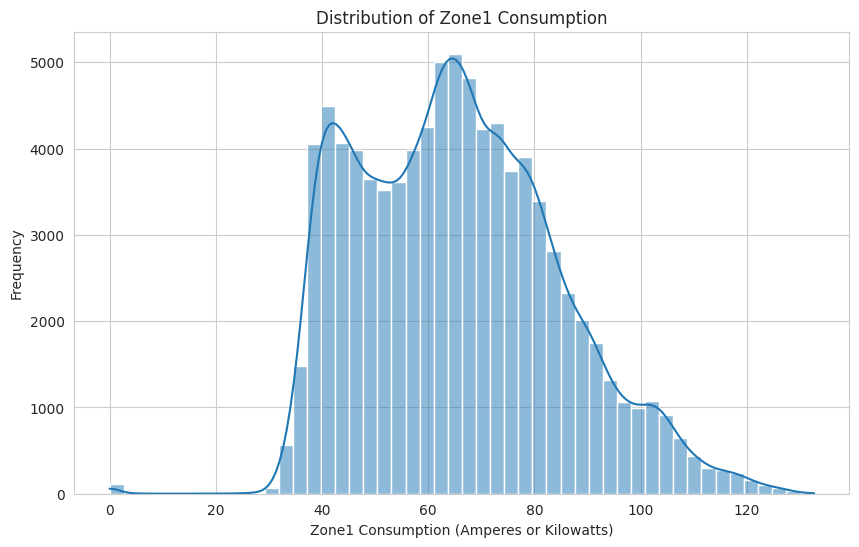

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Plot 1: Histogram of zone1 (Target Variable Distribution)
fig1 = plt.figure(figsize=(10, 6))
sns.histplot(df['zone1'], kde=True, bins=50)
plt.title('Distribution of Zone1 Consumption')
plt.xlabel('Zone1 Consumption (Amperes or Kilowatts)')
plt.ylabel('Frequency')
plt.show()


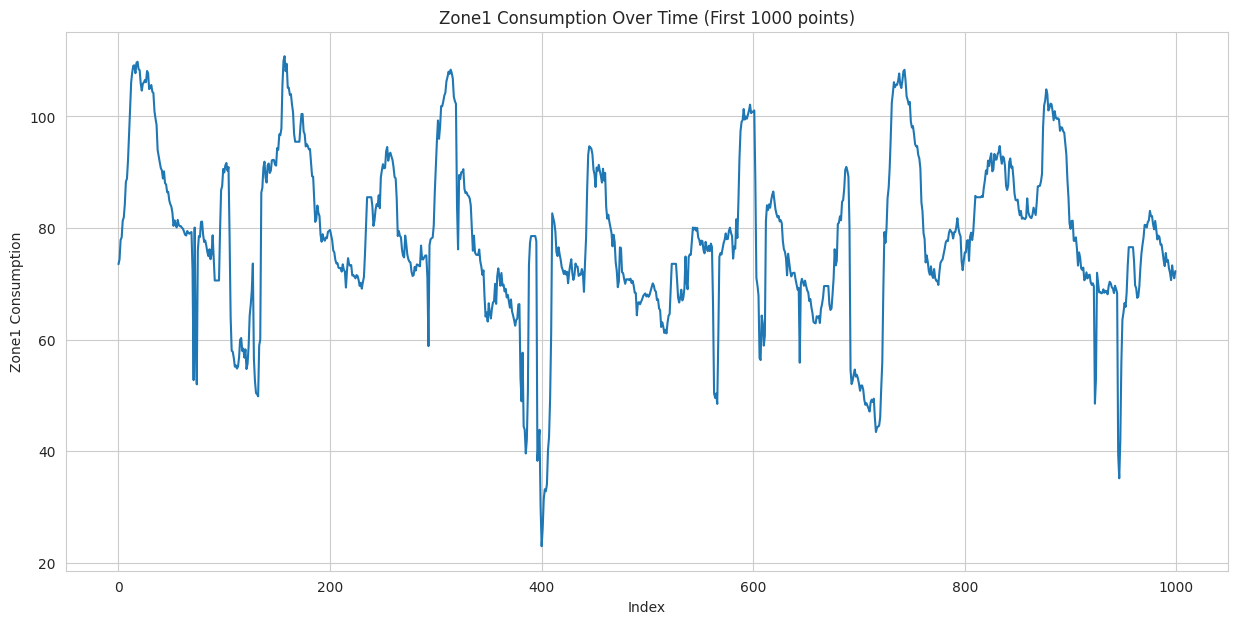

In [20]:
# Plot 2: Time Series Plot of zone1 (first 1000 data points for clarity)
fig2 = plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index[:1000], y=df['zone1'][:1000])
plt.title('Zone1 Consumption Over Time (First 1000 points)')
plt.xlabel('Index')
plt.ylabel('Zone1 Consumption')
plt.show()

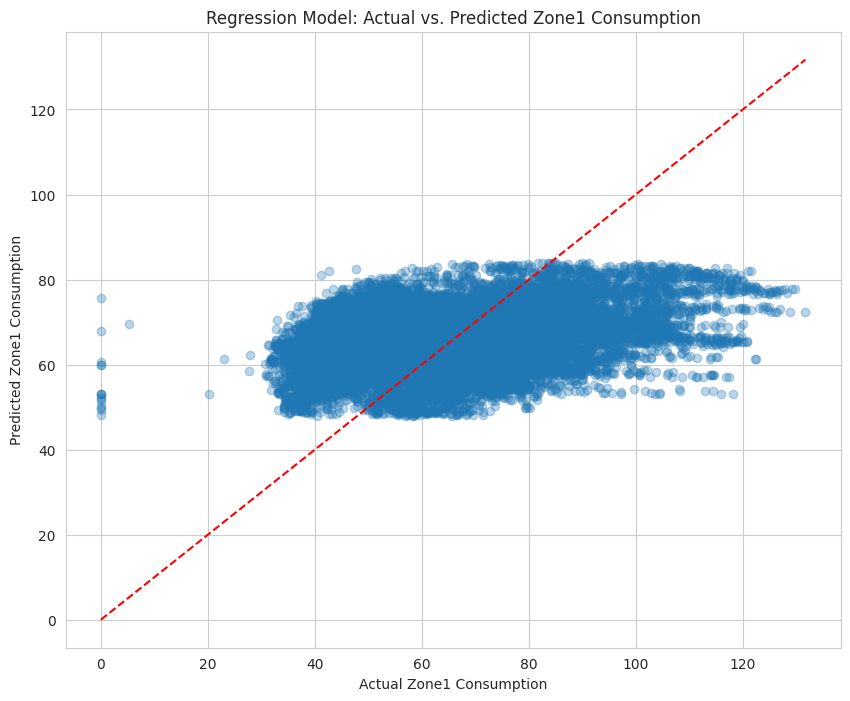

In [21]:
# Plot 3: Actual vs. Predicted values for Regression Model (Test Set)
fig3 = plt.figure(figsize=(10, 8))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Zone1 Consumption')
plt.ylabel('Predicted Zone1 Consumption')
plt.title('Regression Model: Actual vs. Predicted Zone1 Consumption')
plt.show()

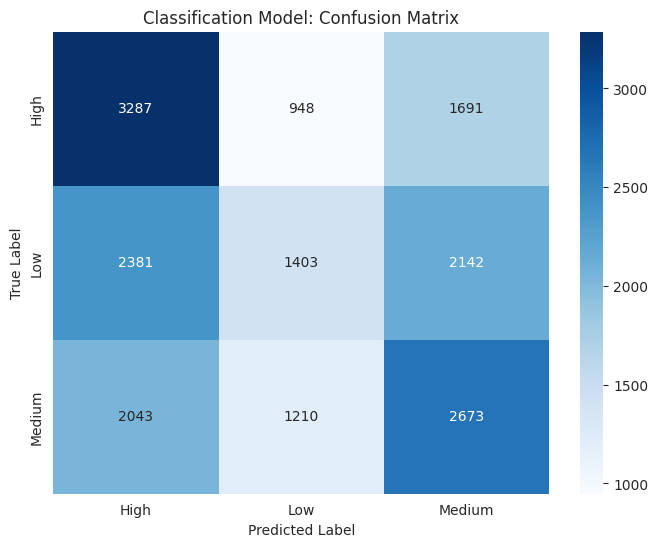

In [22]:
# Plot 4: Confusion Matrix for Classification Model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.title('Classification Model: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5. Feature Scaling and Re-evaluation of Models

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features for regression
X_scaled_reg = scaler.fit_transform(X)
X_train_reg_scaled, X_test_reg_scaled, y_train_reg, y_test_reg = train_test_split(X_scaled_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features for classification
X_scaled_clf = scaler.fit_transform(X_clf)
X_train_clf_scaled, X_test_clf_scaled, y_train_clf, y_test_clf = train_test_split(X_scaled_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print("Features scaled successfully. Retraining models with scaled data.")

Features scaled successfully. Retraining models with scaled data.


#### Re-evaluating Regression Model with Scaled Features

In [24]:
# Initialize and train the Linear Regression model with scaled data
scaled_linear_model = LinearRegression()
scaled_linear_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions on the scaled test set
y_pred_reg_scaled = scaled_linear_model.predict(X_test_reg_scaled)

# Evaluate the model
mae_scaled = mean_absolute_error(y_test_reg, y_pred_reg_scaled)
mse_scaled = mean_squared_error(y_test_reg, y_pred_reg_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test_reg, y_pred_reg_scaled)

print(f"Scaled Regression Model - Mean Absolute Error (MAE): {mae_scaled:.2f}")
print(f"Scaled Regression Model - Mean Squared Error (MSE): {mse_scaled:.2f}")
print(f"Scaled Regression Model - Root Mean Squared Error (RMSE): {rmse_scaled:.2f}")
print(f"Scaled Regression Model - R-squared (R2): {r2_scaled:.2f}")

Scaled Regression Model - Mean Absolute Error (MAE): 14.28
Scaled Regression Model - Mean Squared Error (MSE): 304.68
Scaled Regression Model - Root Mean Squared Error (RMSE): 17.45
Scaled Regression Model - R-squared (R2): 0.15


#### Re-evaluating Classification Model with Scaled Features

In [25]:
# Initialize and train the Logistic Regression model with scaled data
scaled_logistic_model = LogisticRegression(random_state=42, multi_class='ovr', solver='liblinear')
scaled_logistic_model.fit(X_train_clf_scaled, y_train_clf)

# Make predictions on the scaled test set
y_pred_clf_scaled = scaled_logistic_model.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_scaled = accuracy_score(y_test_clf, y_pred_clf_scaled)

print(f"Scaled Classification Model - Accuracy: {accuracy_scaled:.2f}")
print("\nScaled Classification Model - Classification Report:")
print(classification_report(y_test_clf, y_pred_clf_scaled))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Scaled Classification Model - Accuracy: 0.46

Scaled Classification Model - Classification Report:
              precision    recall  f1-score   support

        High       0.49      0.62      0.55      5926
         Low       0.46      0.44      0.45      5926
      Medium       0.42      0.32      0.37      5926

    accuracy                           0.46     17778
   macro avg       0.46      0.46      0.45     17778
weighted avg       0.46      0.46      0.45     17778



### 6. Exploring More Advanced Models: Random Forest

#### Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model with scaled data
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_regressor.fit(X_train_reg_scaled, y_train_reg)

print("Random Forest Regressor model training complete.")

Random Forest Regressor model training complete.


In [27]:
# Make predictions on the scaled test set
y_pred_rf_reg = rf_regressor.predict(X_test_reg_scaled)

# Evaluate the Random Forest Regressor model
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf_reg:.2f}")
print(f"Random Forest Regressor - Mean Squared Error (MSE): {mse_rf_reg:.2f}")
print(f"Random Forest Regressor - Root Mean Squared Error (RMSE): {rmse_rf_reg:.2f}")
print(f"Random Forest Regressor - R-squared (R2): {r2_rf_reg:.2f}")

Random Forest Regressor - Mean Absolute Error (MAE): 2.26
Random Forest Regressor - Mean Squared Error (MSE): 20.39
Random Forest Regressor - Root Mean Squared Error (RMSE): 4.52
Random Forest Regressor - R-squared (R2): 0.94


#### Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model with scaled data
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_classifier.fit(X_train_clf_scaled, y_train_clf)

print("Random Forest Classifier model training complete.")

Random Forest Classifier model training complete.


In [29]:
# Make predictions on the scaled test set
y_pred_rf_clf = rf_classifier.predict(X_test_clf_scaled)

# Evaluate the Random Forest Classifier model
accuracy_rf_clf = accuracy_score(y_test_clf, y_pred_rf_clf)

print(f"Random Forest Classifier - Accuracy: {accuracy_rf_clf:.2f}")
print("\nRandom Forest Classifier - Classification Report:")
print(classification_report(y_test_clf, y_pred_rf_clf))

Random Forest Classifier - Accuracy: 0.91

Random Forest Classifier - Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.93      0.93      5926
         Low       0.93      0.93      0.93      5926
      Medium       0.87      0.88      0.88      5926

    accuracy                           0.91     17778
   macro avg       0.91      0.91      0.91     17778
weighted avg       0.91      0.91      0.91     17778



### 7. Feature Importance from Random Forest Models

One of the benefits of tree-based models like Random Forest is that they can provide insights into which features were most important for making predictions. Let's visualize the feature importances for both the regression and classification Random Forest models.

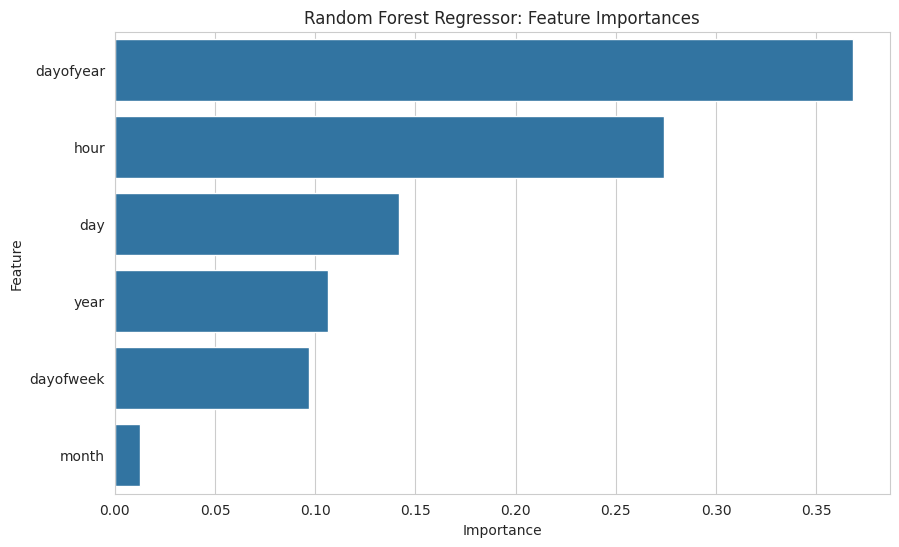

In [30]:
# Get feature importances from the Random Forest Regressor
feature_importances_reg = pd.Series(rf_regressor.feature_importances_, index=X.columns)

# Sort them for better visualization
feature_importances_reg = feature_importances_reg.sort_values(ascending=False)

# Plotting feature importances for Regression
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_reg, y=feature_importances_reg.index)
plt.title('Random Forest Regressor: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

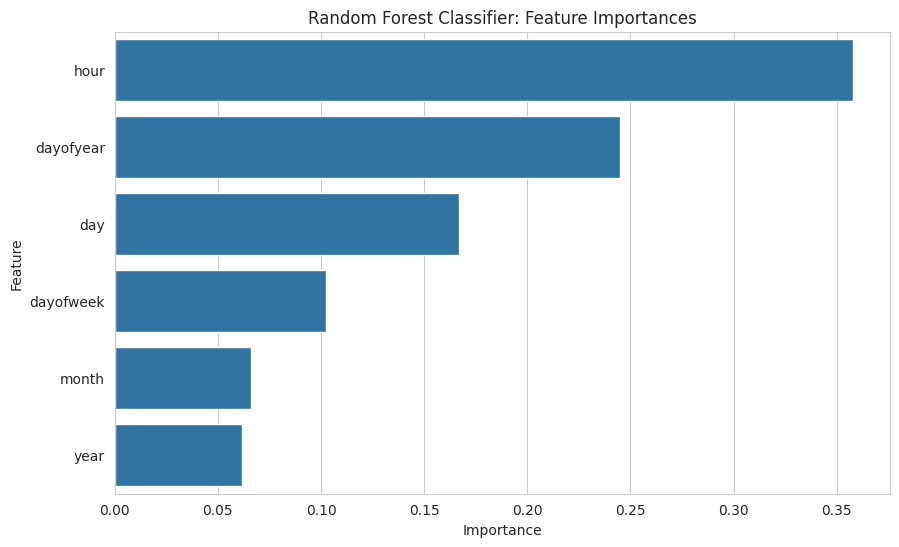

In [31]:
# Get feature importances from the Random Forest Classifier
feature_importances_clf = pd.Series(rf_classifier.feature_importances_, index=X_clf.columns)

# Sort them for better visualization
feature_importances_clf = feature_importances_clf.sort_values(ascending=False)

# Plotting feature importances for Classification
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_clf, y=feature_importances_clf.index)
plt.title('Random Forest Classifier: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 8. Visualizing Random Forest Model Performance

#### Random Forest Regressor: Actual vs. Predicted Values

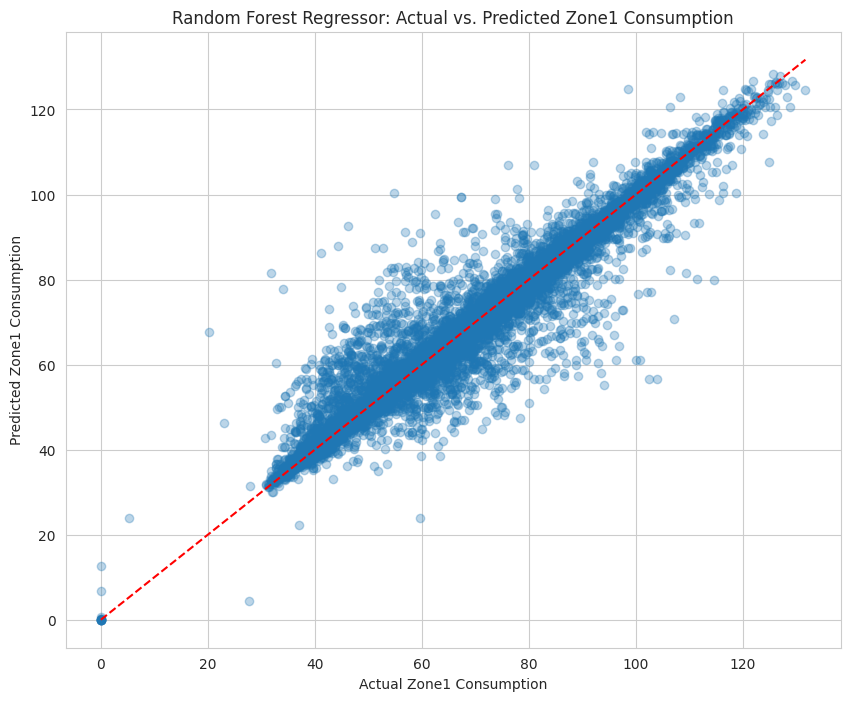

In [32]:
# Plot for Random Forest Regressor: Actual vs. Predicted values (Test Set)
plt.figure(figsize=(10, 8))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Zone1 Consumption')
plt.ylabel('Predicted Zone1 Consumption')
plt.title('Random Forest Regressor: Actual vs. Predicted Zone1 Consumption')
plt.show()

#### Random Forest Classifier: Confusion Matrix

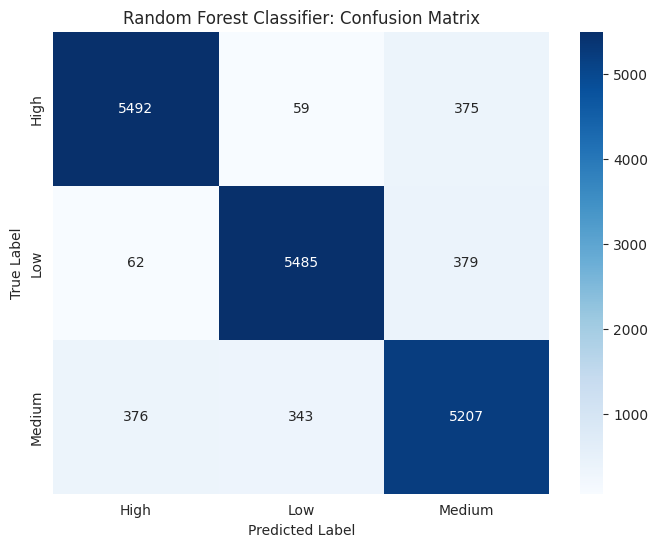

In [33]:
# Confusion Matrix for Random Forest Classifier
cm_rf_clf = confusion_matrix(y_test_clf, y_pred_rf_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_clf, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Random Forest Classifier: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 9. Hyperparameter Tuning for Random Forest Models

To further optimize the performance of our Random Forest models, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameters, evaluating each using cross-validation, to find the best set.

#### Hyperparameter Tuning for Random Forest Regressor

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest Regressor
param_grid_reg = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_features': [0.6, 0.8, 1.0], # Number of features to consider when looking for the best split
    'min_samples_leaf': [1, 2],       # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_reg,
    cv=3, # Using 3-fold cross-validation for reasonable computation time
    scoring='r2', # Maximize R-squared for regression
    verbose=2, # Verbose output to see progress
    n_jobs=-1 # Use all available CPU cores
)

print("Starting GridSearchCV for Random Forest Regressor...")
# Fit GridSearchCV to the scaled training data
grid_search_reg.fit(X_train_reg_scaled, y_train_reg)

print("GridSearchCV for Random Forest Regressor complete.")

Starting GridSearchCV for Random Forest Regressor...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


In [ ]:
# Get the best parameters and best score for the Regressor
best_params_reg = grid_search_reg.best_params_
best_score_reg = grid_search_reg.best_score_

print(f"Best parameters for Random Forest Regressor: {best_params_reg}")
print(f"Best R-squared from GridSearchCV (Regressor): {best_score_reg:.2f}")

# Evaluate the best Regressor model on the test set
best_rf_regressor = grid_search_reg.best_estimator_
y_pred_tuned_rf_reg = best_rf_regressor.predict(X_test_reg_scaled)

mae_tuned_rf_reg = mean_absolute_error(y_test_reg, y_pred_tuned_rf_reg)
mse_tuned_rf_reg = mean_squared_error(y_test_reg, y_pred_tuned_rf_reg)
rmse_tuned_rf_reg = np.sqrt(mse_tuned_rf_reg)
r2_tuned_rf_reg = r2_score(y_test_reg, y_pred_tuned_rf_reg)

print(f"Tuned Random Forest Regressor - MAE on test set: {mae_tuned_rf_reg:.2f}")
print(f"Tuned Random Forest Regressor - MSE on test set: {mse_tuned_rf_reg:.2f}")
print(f"Tuned Random Forest Regressor - RMSE on test set: {rmse_tuned_rf_reg:.2f}")
print(f"Tuned Random Forest Regressor - R-squared on test set: {r2_tuned_rf_reg:.2f}")

#### Hyperparameter Tuning for Random Forest Classifier

In [ ]:
# Define the parameter grid for Random Forest Classifier
param_grid_clf = {
    'n_estimators': [50, 100, 150],
    'max_features': [0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 2],
}

# Initialize GridSearchCV
grid_search_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_clf,
    cv=3, # Using 3-fold cross-validation
    scoring='accuracy', # Maximize accuracy for classification
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV for Random Forest Classifier...")
# Fit GridSearchCV to the scaled training data
grid_search_clf.fit(X_train_clf_scaled, y_train_clf)

print("GridSearchCV for Random Forest Classifier complete.")

In [ ]:
# Get the best parameters and best score for the Classifier
best_params_clf = grid_search_clf.best_params_
best_score_clf = grid_search_clf.best_score_

print(f"Best parameters for Random Forest Classifier: {best_params_clf}")
print(f"Best Accuracy from GridSearchCV (Classifier): {best_score_clf:.2f}")

# Evaluate the best Classifier model on the test set
best_rf_classifier = grid_search_clf.best_estimator_
y_pred_tuned_rf_clf = best_rf_classifier.predict(X_test_clf_scaled)

accuracy_tuned_rf_clf = accuracy_score(y_test_clf, y_pred_tuned_rf_clf)

print(f"Tuned Random Forest Classifier - Accuracy on test set: {accuracy_tuned_rf_clf:.2f}")
print("\nTuned Random Forest Classifier - Classification Report on test set:")
print(classification_report(y_test_clf, y_pred_tuned_rf_clf))

### 10. K-Fold Cross-Validation for Tuned Random Forest Models

Now, let's perform k-fold cross-validation on our best-tuned Random Forest models to obtain a more robust estimate of their performance. We will use `cv=5` (5-fold cross-validation) for this assessment.

#### K-Fold Cross-Validation for Tuned Random Forest Regressor

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Use the best_rf_regressor obtained from GridSearchCV

# Define KFold cross-validator
kf_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and calculate R-squared scores
cv_scores_r2_reg = cross_val_score(best_rf_regressor, X_scaled_reg, y_reg, cv=kf_reg, scoring='r2', n_jobs=-1)
cv_scores_mae_reg = cross_val_score(best_rf_regressor, X_scaled_reg, y_reg, cv=kf_reg, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_mse_reg = cross_val_score(best_rf_regressor, X_scaled_reg, y_reg, cv=kf_reg, scoring='neg_mean_squared_error', n_jobs=-1)

print(f"Tuned Random Forest Regressor - Cross-Validation R-squared scores: {cv_scores_r2_reg}")
print(f"Tuned Random Forest Regressor - Mean CV R-squared: {np.mean(cv_scores_r2_reg):.2f} (+/- {np.std(cv_scores_r2_reg):.2f})")
print(f"Tuned Random Forest Regressor - Mean CV MAE: {np.mean(-cv_scores_mae_reg):.2f} (+/- {np.std(-cv_scores_mae_reg):.2f})")
print(f"Tuned Random Forest Regressor - Mean CV RMSE: {np.mean(np.sqrt(-cv_scores_mse_reg)):.2f} (+/- {np.std(np.sqrt(-cv_scores_mse_reg)):.2f})")

#### K-Fold Cross-Validation for Tuned Random Forest Classifier

In [ ]:
# Use the best_rf_classifier obtained from GridSearchCV

# Define KFold cross-validator (stratified for classification)
kf_clf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and calculate accuracy scores
cv_scores_accuracy_clf = cross_val_score(best_rf_classifier, X_scaled_clf, y_clf, cv=kf_clf, scoring='accuracy', n_jobs=-1)

print(f"Tuned Random Forest Classifier - Cross-Validation Accuracy scores: {cv_scores_accuracy_clf}")
print(f"Tuned Random Forest Classifier - Mean CV Accuracy: {np.mean(cv_scores_accuracy_clf):.2f} (+/- {np.std(cv_scores_accuracy_clf):.2f})")

# We can also get per-class F1-scores, precision, recall using cross_validate and returning multiple metrics
from sklearn.model_selection import cross_validate

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
cv_results_clf = cross_validate(best_rf_classifier, X_scaled_clf, y_clf, cv=kf_clf, scoring=scoring_metrics, n_jobs=-1)

print("\nTuned Random Forest Classifier - Detailed Cross-Validation Results:")
for metric_name in scoring_metrics:
    mean_score = np.mean(cv_results_clf[f'test_{metric_name}'])
    std_score = np.std(cv_results_clf[f'test_{metric_name}'])
    print(f"Mean CV {metric_name.replace('_weighted', ' (Weighted)'):<25}: {mean_score:.2f} (+/- {std_score:.2f})")